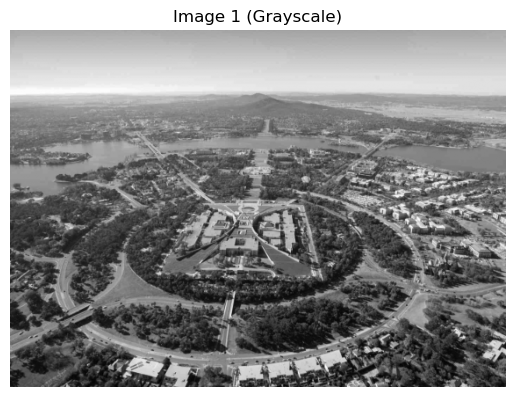

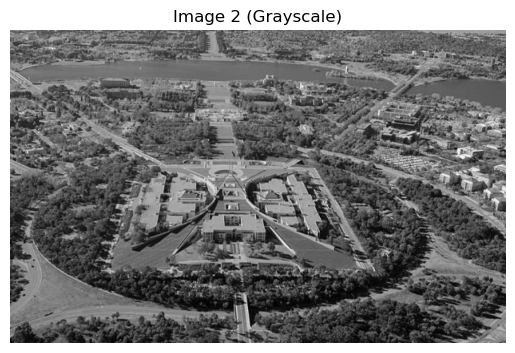

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Load two images
img1 = cv2.imread('canberra1.png')
img2 = cv2.imread('canberra2.png')
# Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
# Display the first image
plt.imshow(gray1, cmap='gray')
plt.title("Image 1 (Grayscale)")
plt.axis("off")
plt.show()
plt.imshow(gray2, cmap='gray')
plt.title("Image 2 (Grayscale)")
plt.axis("off")
plt.show()

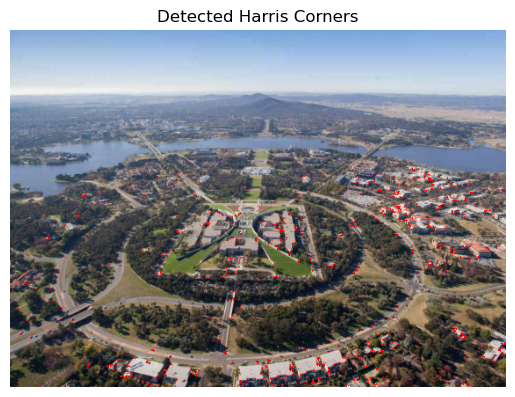

In [2]:
# Harris corner detection requires float32 images
gray1_float = np.float32(gray1)
# Apply Harris Corner Detector
dst = cv2.cornerHarris(gray1_float, blockSize=2, ksize=3, k=0.04)
# Create a copy for visualization
img_harris = img1.copy()
# Mark strong corners in red
img_harris[dst > 0.05 * dst.max()] = [0, 0, 255]
# Display results
plt.imshow(cv2.cvtColor(img_harris, cv2.COLOR_BGR2RGB))
plt.title("Detected Harris Corners")
plt.axis("off")
plt.show()

In [ ]:
# Create SIFT detector
sift = cv2.SIFT_create() #creating sift
# Detect keypoints and compute descriptors
kp1, des1 = sift.detectAndCompute(gray1, None) #using sift
kp2, des2 = sift.detectAndCompute(gray2, None)
print("Number of keypoints in image 1:", len(kp1))
print("Number of keypoints in image 2:", len(kp2)) #printing sift point

Number of keypoints in image 1: 3238
Number of keypoints in image 2: 4311


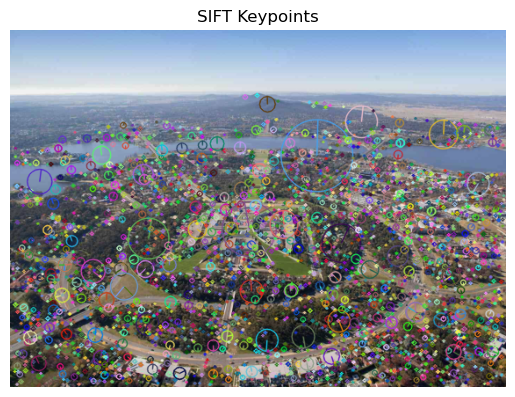

In [ ]:
img_sift = cv2.drawKeypoints(
img1, #use umage
kp1, #use sift
None,
flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS #only good
) 
plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
plt.title("SIFT Keypoints")
plt.axis("off")
plt.show() #show me 

In [ ]:
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True) #make matcher 
matches = bf.match(des1, des2) #use matcher
# Sort matches based on descriptor distance
matches = sorted(matches, key=lambda x: x.distance) #sort by distance
print("Total matches found:", len(matches))

Total matches found: 1392


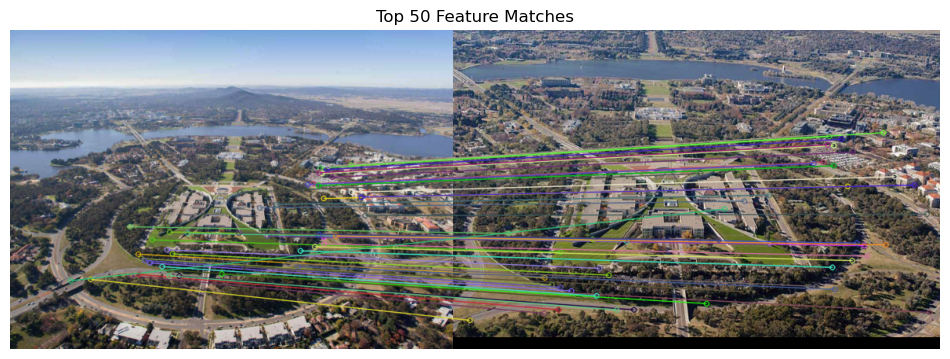

In [7]:
matched_img = cv2.drawMatches(
img1, kp1,
img2, kp2,
matches[:50], None,
flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title("Top 50 Feature Matches")
plt.axis("off")
plt.show()

In [8]:
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)
print("Good matches after ratio test:", len(good_matches))

Good matches after ratio test: 237


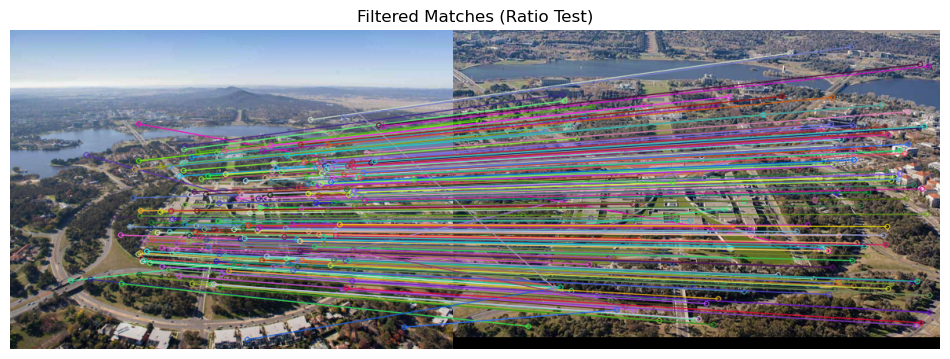

In [9]:
# Visualize Filtered Matches
matched_img = cv2.drawMatches(
img1, kp1,
img2, kp2,
good_matches, None,
flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title("Filtered Matches (Ratio Test)")
plt.axis("off")
plt.show()